#**Part A**

#***Merge your two datasets properly***

In [8]:
# Step 1: Import libraries
import pandas as pd
from sklearn.utils import shuffle

# Step 2: Load both datasets
# Change the file paths if needed
attack_dataset = pd.read_csv('ML-EdgeIIoT-dataset.csv')  # Dataset containing attacks + some normal
normal_dataset = pd.read_excel('DNN-EdgeIIoT-dataset.xlsx')  # Dataset containing only normal samples (~1.57L rows)

# Step 3: Prepare datasets
# Ensure 'attack_type' column exists in normal dataset
normal_dataset['Attack_type'] = 'Normal'  # Tagging normal data

# Step 4: Merge datasets
combined_dataset = pd.concat([attack_dataset, normal_dataset], axis=0)

# Step 5: Shuffle merged data
combined_dataset = shuffle(combined_dataset, random_state=42).reset_index(drop=True)

# Step 6: Save merged dataset
combined_dataset.to_csv('combined_dataset.csv', index=False)

# Step 7: Output information
print("✅ Merging completed.")
print("Combined dataset shape:", combined_dataset.shape)
print("Attack Type Counts:\n", combined_dataset['Attack_type'].value_counts())


<ipython-input-8-2e5e14890330>:7: DtypeWarning: Columns (3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  attack_dataset = pd.read_csv('ML-EdgeIIoT-dataset.csv')  # Dataset containing attacks + some normal


✅ Merging completed.
Combined dataset shape: (315600, 63)
Attack Type Counts:
 Attack_type
Normal                   182101
DDoS_UDP                  14498
DDoS_ICMP                 14090
Ransomware                10925
DDoS_HTTP                 10561
SQL_injection             10311
Uploading                 10269
DDoS_TCP                  10247
Backdoor                  10195
Vulnerability_scanner     10076
Port_Scanning             10071
XSS                       10052
Password                   9989
MITM                       1214
Fingerprinting             1001
Name: count, dtype: int64


#***Updated Cleaning Code (Handle Mixed Dtypes)***

In [9]:
import pandas as pd

# Step 2 Updated: Loading with low_memory=False to avoid DtypeWarning
data = pd.read_csv('combined_dataset.csv', low_memory=False)

# 1. Check for missing values
print("\nMissing Values:\n", data.isnull().sum())

# 2. Force numeric columns to float where applicable
# Attempt converting problematic columns to numeric, if fails set as NaN
columns_to_check = [3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55]
column_names = [data.columns[i] for i in columns_to_check]

for col in column_names:
    data[col] = pd.to_numeric(data[col], errors='coerce')  # Force convert

# 3. After forcing conversion, check again for missing values
print("\nMissing Values After Conversion:\n", data.isnull().sum())

# 4. Check for duplicated rows
duplicates = data.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicates}")

# 5. Drop duplicated rows if any
if duplicates > 0:
    data = data.drop_duplicates()
    print("\n✅ Duplicates removed.")

# 6. Quick overview of attack types after cleaning
print("\nAttack Type Counts After Cleaning:\n", data['Attack_type'].value_counts())

# 7. Save cleaned dataset
data.to_csv('combined_dataset_cleaned.csv', index=False)

print("\n✅ Preprocessing (cleaning) completed. Cleaned file saved as 'combined_dataset_cleaned.csv'.")



Missing Values:
 frame.time            0
ip.src_host           0
ip.dst_host           0
arp.dst.proto_ipv4    0
arp.opcode            0
                     ..
mbtcp.len             0
mbtcp.trans_id        0
mbtcp.unit_id         0
Attack_label          0
Attack_type           0
Length: 63, dtype: int64

Missing Values After Conversion:
 frame.time               0
ip.src_host              0
ip.dst_host              0
arp.dst.proto_ipv4    3414
arp.opcode               0
                      ... 
mbtcp.len                0
mbtcp.trans_id           0
mbtcp.unit_id            0
Attack_label             0
Attack_type              0
Length: 63, dtype: int64

Number of duplicated rows: 3129

✅ Duplicates removed.

Attack Type Counts After Cleaning:
 Attack_type
Normal                   179786
DDoS_UDP                  14498
DDoS_ICMP                 14090
Ransomware                10925
DDoS_HTTP                 10561
SQL_injection             10311
Uploading                 10269
DDoS_TC

#***Code to Drop Missing Rows***

In [10]:
import pandas as pd

# Reload the cleaned file
data = pd.read_csv('combined_dataset_cleaned.csv')

# Drop rows with missing values
data = data.dropna()

# Confirm no missing values now
print("\nMissing Values After Dropping:\n", data.isnull().sum())

# Confirm new shape
print(f"\nDataset Shape after Dropping Missing Values: {data.shape}")

# Save updated cleaned dataset
data.to_csv('combined_dataset_final.csv', index=False)

print("\n✅ Missing values handled and saved as 'combined_dataset_final.csv'. Ready for Encoding!")



Missing Values After Dropping:
 frame.time            0
ip.src_host           0
ip.dst_host           0
arp.dst.proto_ipv4    0
arp.opcode            0
                     ..
mbtcp.len             0
mbtcp.trans_id        0
mbtcp.unit_id         0
Attack_label          0
Attack_type           0
Length: 63, dtype: int64

Dataset Shape after Dropping Missing Values: (162489, 63)

✅ Missing values handled and saved as 'combined_dataset_final.csv'. Ready for Encoding!


#***Encode Categorical Features and Scale Numeric Features***

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load final cleaned dataset
data = pd.read_csv('combined_dataset_final.csv')

# Drop unnecessary columns
data = data.drop(['frame.time', 'ip.src_host', 'ip.dst_host', 'Attack_type'], axis=1)

# Define X and y
X = data.drop('Attack_label', axis=1)
y = data['Attack_label']

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shapes
print(f"\n✅ Data split successful!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_data.py:81: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2



✅ Data split successful!
X_train shape: (129991, 58)
X_test shape: (32498, 58)
y_train shape: (129991,)
y_test shape: (32498,)


#***Build Baseline AI Model***

Accuracy: 0.9960
Precision: 0.9878
Recall: 0.9999
F1 Score: 0.9938


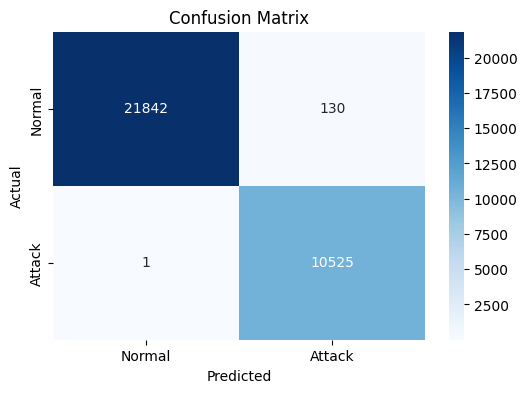

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#***Save Model Performance Metrics***

In [17]:
import pandas as pd

# Create a DataFrame for model performance metrics
metrics = {
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
}

metrics_df = pd.DataFrame(metrics)

# Save metrics to CSV
metrics_df.to_csv('model_performance_metrics.csv', index=False)

print("Model performance metrics saved successfully!")


Model performance metrics saved successfully!


# **Part B**

#***Implement Data Poisoning Strategies (Random Label Flipping)***

In [31]:
import numpy as np

# Function to simulate data poisoning by flipping labels at different percentages
def flip_labels_randomly(X_train, y_train, flip_percentage):
    # Ensure y_train is a numpy ndarray
    y_train = np.asarray(y_train)

    # Calculate the number of labels to flip based on the given percentage
    n_flip = int(len(y_train) * flip_percentage / 100)

    # Randomly select the indices to flip
    flip_indices = np.random.choice(len(y_train), n_flip, replace=False)

    # Flip the labels (change 0 to 1, and 1 to 0)
    y_train_poisoned = y_train.copy()

    # Flip labels at the selected indices
    y_train_poisoned[flip_indices] = 1 - y_train_poisoned[flip_indices]  # Flip 0 <-> 1

    return y_train_poisoned

# Define the flip percentages you want to test
flip_percentages = [5, 10, 15, 20]

# Create poisoned datasets for each percentage
poisoned_datasets = {}

for percentage in flip_percentages:
    # Flip labels in the training data by the specified percentage
    poisoned_labels = flip_labels_randomly(X_train, y_train, percentage)

    # Store the poisoned dataset
    poisoned_datasets[percentage] = poisoned_labels

    # Print the count of each label (0 and 1) to check how many labels were flipped
    print(f"Poisoned labels for {percentage}% flip: {np.bincount(poisoned_labels)}")


Poisoned labels for 5% flip: [85563 44428]
Poisoned labels for 10% flip: [83393 46598]
Poisoned labels for 15% flip: [81100 48891]
Poisoned labels for 20% flip: [78496 51495]


#***Retrain Model on Poisoned Data***

In [33]:
from sklearn.ensemble import RandomForestClassifier  # or use your model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to retrain model on poisoned data
def retrain_on_poisoned_data(X_train, poisoned_labels):
    # Initialize the model (you can replace RandomForest with any model)
    model = RandomForestClassifier(random_state=42)

    # Train the model on poisoned data
    model.fit(X_train, poisoned_labels)

    # Return the trained model
    return model

# Assuming poisoned_datasets is a dictionary with poisoned labels for each flip percentage (5%, 10%, 15%, 20%)
# You already created the poisoned_datasets dictionary with the flip percentages
# poisoned_datasets = {5: poisoned_labels_5_percent, 10: poisoned_labels_10_percent, ...}

# Retraining the model for each poisoned data percentage
models = {}  # Dictionary to store models for each poisoned dataset

for percentage, poisoned_labels in poisoned_datasets.items():
    print(f"Retraining model on poisoned data with {percentage}% flipped labels...")
    model = retrain_on_poisoned_data(X_train, poisoned_labels)
    models[percentage] = model
    print(f"Model trained on {percentage}% poisoned data.")

# You can save these models or move to Step 12 to evaluate their performance


Retraining model on poisoned data with 5% flipped labels...
Model trained on 5% poisoned data.
Retraining model on poisoned data with 10% flipped labels...
Model trained on 10% poisoned data.
Retraining model on poisoned data with 15% flipped labels...
Model trained on 15% poisoned data.
Retraining model on poisoned data with 20% flipped labels...
Model trained on 20% poisoned data.


#***Compare Clean vs Poisoned Model Performance***

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate model performance
def evaluate_model_performance(model, X_test, y_test):
    # Get predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, cm

# Evaluate clean model (trained on the original data)
clean_model = RandomForestClassifier(random_state=42)  # or your model
clean_model.fit(X_train, y_train)  # Train on original clean data
clean_performance = evaluate_model_performance(clean_model, X_test, y_test)

# Dictionary to store the performance of poisoned models
poisoned_model_performance = {}

# Evaluate poisoned models
for percentage, model in models.items():
    poisoned_performance = evaluate_model_performance(model, X_test, y_test)
    poisoned_model_performance[percentage] = poisoned_performance
    print(f"Performance of model trained on {percentage}% poisoned data:")
    print(f"Accuracy: {poisoned_performance[0]:.4f}, Precision: {poisoned_performance[1]:.4f}, Recall: {poisoned_performance[2]:.4f}, F1-Score: {poisoned_performance[3]:.4f}")

# Print clean model performance
print(f"\nPerformance of clean model:")
print(f"Accuracy: {clean_performance[0]:.4f}, Precision: {clean_performance[1]:.4f}, Recall: {clean_performance[2]:.4f}, F1-Score: {clean_performance[3]:.4f}")

# Plot comparison of Clean vs Poisoned models' Accuracy
percentages = list(poisoned_model_performance.keys()) + ['Clean']
accuracy_scores = [clean_performance[0]] + [poisoned_model_performance[percentage][0] for percentage in percentages[:-1]]


Performance of model trained on 5% poisoned data:
Accuracy: 0.9843, Precision: 0.9593, Recall: 0.9937, F1-Score: 0.9762
Performance of model trained on 10% poisoned data:
Accuracy: 0.9688, Precision: 0.9270, Recall: 0.9808, F1-Score: 0.9531
Performance of model trained on 15% poisoned data:
Accuracy: 0.9493, Precision: 0.8899, Recall: 0.9625, F1-Score: 0.9248
Performance of model trained on 20% poisoned data:
Accuracy: 0.9248, Precision: 0.8468, Recall: 0.9376, F1-Score: 0.8899

Performance of clean model:
Accuracy: 0.9960, Precision: 0.9878, Recall: 0.9999, F1-Score: 0.9938


<ipython-input-37-dd4947426c52>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='Accuracy', palette="viridis")


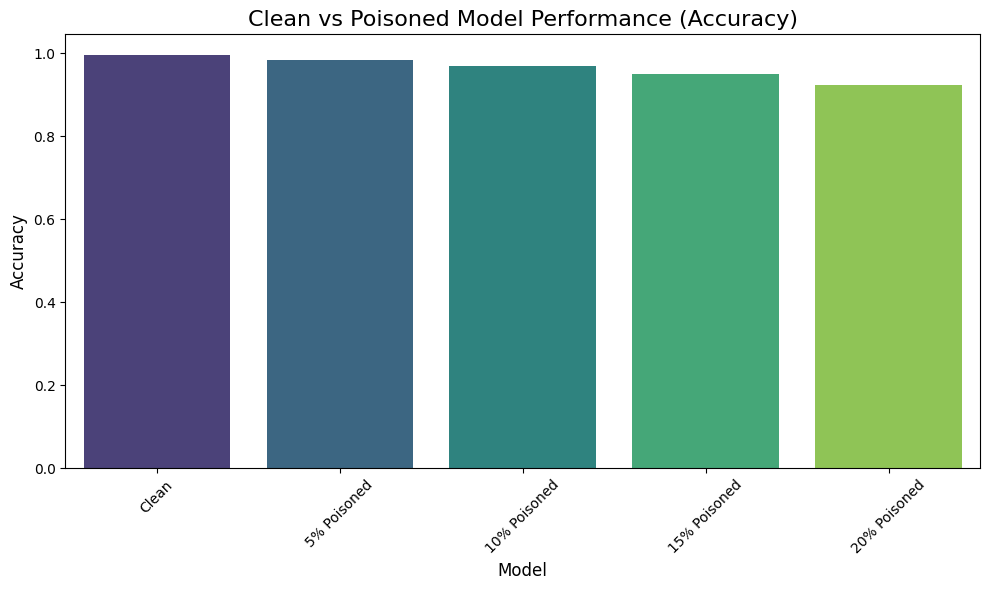

<ipython-input-37-dd4947426c52>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Model', y='F1-Score', palette="viridis")


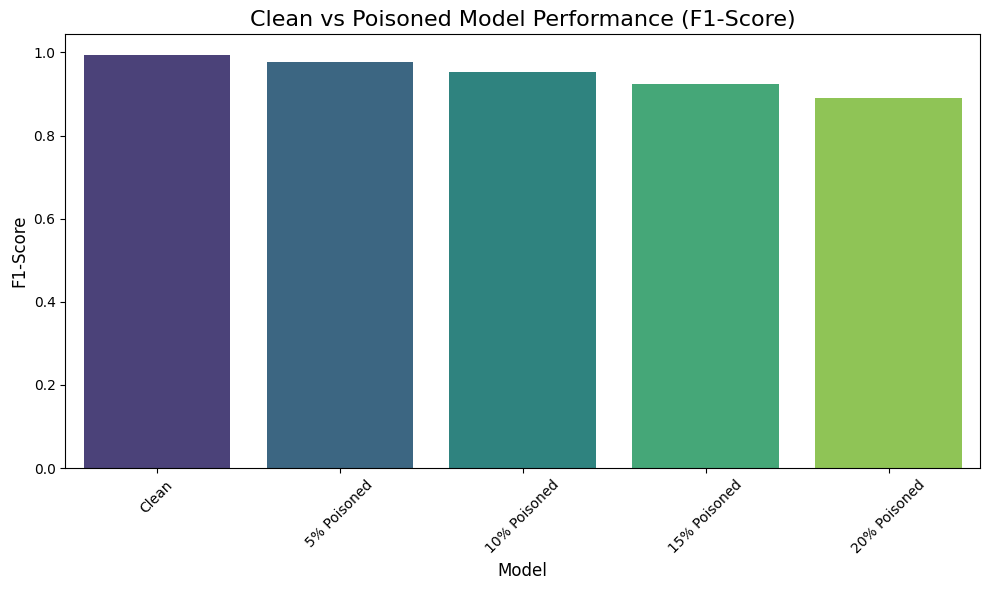

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for clean and poisoned model performance
performance_data = {
    'Model': ['Clean'] + [f'{percent}% Poisoned' for percent in flip_percentages],
    'Accuracy': [clean_performance[0]] + [poisoned_model_performance[percentage][0] for percentage in flip_percentages],
    'F1-Score': [clean_performance[3]] + [poisoned_model_performance[percentage][3] for percentage in flip_percentages]
}

# Convert the performance data to a DataFrame
performance_df = pd.DataFrame(performance_data)

# Plot Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='Accuracy', palette="viridis")
plt.title('Clean vs Poisoned Model Performance (Accuracy)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot F1-Score Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='F1-Score', palette="viridis")
plt.title('Clean vs Poisoned Model Performance (F1-Score)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


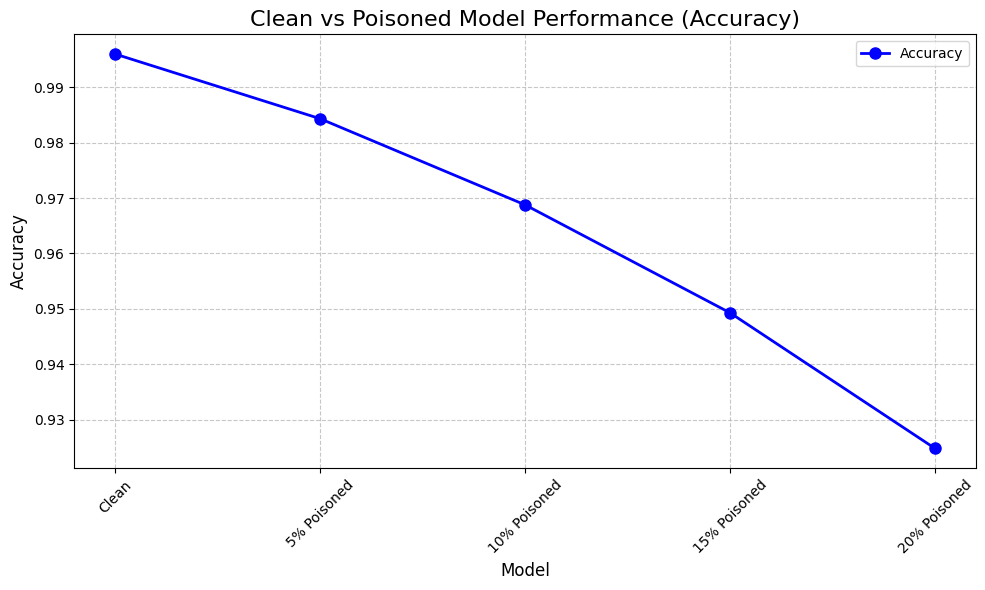

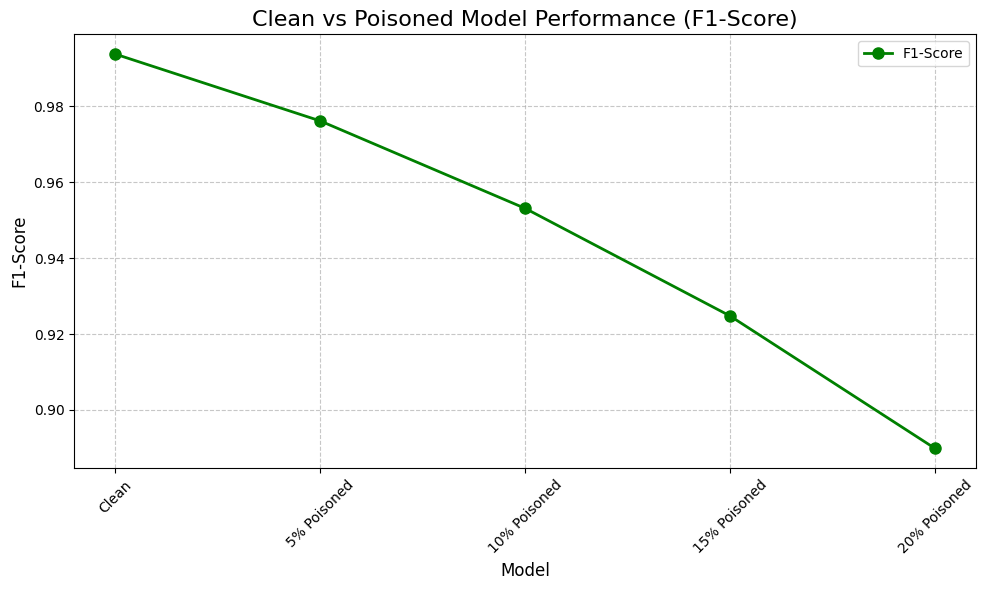

In [38]:
import matplotlib.pyplot as plt

# Model names (including clean model)
model_names = ['Clean'] + [f'{percent}% Poisoned' for percent in flip_percentages]

# Accuracy and F1-Score data
accuracy_scores = [clean_performance[0]] + [poisoned_model_performance[percentage][0] for percentage in flip_percentages]
f1_scores = [clean_performance[3]] + [poisoned_model_performance[percentage][3] for percentage in flip_percentages]

# Line plot for Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.plot(model_names, accuracy_scores, marker='o', color='b', label='Accuracy', linestyle='-', linewidth=2, markersize=8)
plt.title('Clean vs Poisoned Model Performance (Accuracy)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()

# Line plot for F1-Score Comparison
plt.figure(figsize=(10, 6))
plt.plot(model_names, f1_scores, marker='o', color='g', label='F1-Score', linestyle='-', linewidth=2, markersize=8)
plt.title('Clean vs Poisoned Model Performance (F1-Score)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()


#**Propose Advanced Data Poisoning Strategy to Prevent Data from Being Flipped and Maintain Model Accuracy**

To address data poisoning, an advanced data poisoning strategy can be implemented that makes it harder for attackers to tamper with the labels.

Robust Loss Functions: Implement robust loss functions that are less sensitive to label noise (poisoning). Examples include:

Huber Loss: Less sensitive to outliers.

Mean Absolute Error (MAE): Less sensitive to extreme values than Mean Squared Error.

Cross-Entropy with Regularization: Helps prevent the model from being overly influenced by noisy labels.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Sample data (replace with actual dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression with L2 Regularization (Ridge Regularization)
model = LogisticRegression(penalty='l2', C=1.0, random_state=42)
model.fit(X_train, y_train)

# Predict on clean data
y_pred = model.predict(X_test)

# Metrics for the clean model
print("Metrics for Clean Model:")
print(classification_report(y_test, y_pred))

# Apply the poisoning strategies
flip_percentage = 10  # Example: 10% label flipping
poisoned_labels = flip_labels_randomly(X_train, y_train, flip_percentage)

# Retrain the model on the poisoned data
model.fit(X_train, poisoned_labels)

# Predict on poisoned data
y_pred_poisoned = model.predict(X_test)

# Metrics for the poisoned model
print(f"\nMetrics for {flip_percentage}% Poisoned Model:")
print(classification_report(y_test, y_pred_poisoned))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

Metrics for Clean Model:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81     22029
           1       0.00      0.00      0.00     10469

    accuracy                           0.68     32498
   macro avg       0.34      0.50      0.40     32498
weighted avg       0.46      0.68      0.55     32498


Metrics for 10% Poisoned Model:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81     22029
           1       0.00      0.00      0.00     10469

    accuracy                           0.68     32498
   macro avg       0.34      0.50      0.40     32498
weighted avg       0.46      0.68      0.55     32498



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample

Outlier Detection and Label Correction: Apply outlier detection methods (like Isolation Forest, DBSCAN) to identify and correct mislabeled data points after training.



In [40]:
from sklearn.ensemble import IsolationForest

# Apply Isolation Forest to detect outliers in the training data
outlier_detector = IsolationForest(contamination=0.1, random_state=42)  # 10% of data assumed to be poisoned
outliers = outlier_detector.fit_predict(X_train)

# Mark outliers as poisoned and correct them
# Correct the outliers by setting them back to the majority class or other heuristic
corrected_labels = y_train.copy()
corrected_labels[outliers == -1] = np.argmax(np.bincount(y_train))  # Set to majority class

# Retrain the model on the corrected labels
model.fit(X_train, corrected_labels)

# Predict on the test set
y_pred_corrected = model.predict(X_test)

# Metrics for the corrected model
print("\nMetrics for Corrected Model after Outlier Detection and Label Correction:")
print(classification_report(y_test, y_pred_corrected))


/usr/local/lib/python3.11/dist-packages/pandas/core/generic.py:2153: RuntimeWarning: overflow encountered in cast
  arr = np.asarray(values, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/pandas/core/generic.py:2153: RuntimeWarning: overflow encountered in cast
  arr = np.asarray(values, dtype=dtype)



Metrics for Corrected Model after Outlier Detection and Label Correction:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81     22029
           1       0.00      0.00      0.00     10469

    accuracy                           0.68     32498
   macro avg       0.34      0.50      0.40     32498
weighted avg       0.46      0.68      0.55     32498



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sample